In [32]:
import serial
import numpy as np
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

plt.style.use('dark_background')


In [34]:
with serial.Serial("COM6", 115200, rtscts=False) as ser:
    ser.write(b'hello\n')
    l = ser.readline().decode()
    print(l)


NEW Name Here Ready



In [ ]:
cmd = '''
set_currents(60, 30, 50);
set_gains(2, 5, 5, 1, 5, 5);
config();


actinic = 100;


set_arr(1,1,0,1,50,50,0,2);

set_arr(1,2,0,1,250,100,actinic,2);
set_arr(2,1,0,1,450,100,actinic,2);
set_arr(3,1,0,1,50,10,actinic,2);
set_arr(3,2,0,1,450,100,0,2);
set_arr(4,1,0,1,50,10,0,2);


run_mpf(0, 0);
run(1,1);
run_mpf(1, actinic);
for(i=0;i<4;i++){
run(2, 1);
run_mpf(1, actinic);
}

run(3,0);
run_mpf(1,0);
for(i=0;i<4;i++){ 
set_arr(4,1,0,1,50+i*10,5,0,2);
run(4,0);
run_mpf(1,0);
}


'''


In [195]:
cmd = '''
set_currents(110, 30, 50);
set_gains(1, 5, 5, 1, 5, 5);
config();


actinic = 0;


set_arr(1,1,0,1,50,25,0,2);
set_arr(1,2,0,1,50,25,0,2);

run_mpf(0, 0);
run(1,0);

'''

cmd_str = "C:" + cmd + "?"
cmd_str

'C:\nset_currents(110, 30, 50);\nset_gains(1, 5, 5, 1, 5, 5);\nconfig();\n\n\nactinic = 0;\n\n\nset_arr(1,1,0,1,50,25,0,2);\nset_arr(1,2,0,1,50,25,0,2);\n\nrun_mpf(0, 0);\nrun(1,0);\n\n?'

In [196]:
info_outputs = ""
other_outputs = ""
with serial.Serial("COM6", 115200) as ser:
    start_timer = time.time()
    #ser.write("mpf, 0, 100, 100".encode())
    #ser.write("arrun, 500, 500, 0, 0, 0".encode())
    ser.write(cmd_str.encode())
    
    data = {}

    while (time.time() - start_timer < 3000):
        if ser.in_waiting > 2:
            start_timer = time.time()
            l = ser.readline().decode().strip()
            if l[0] == '[':
                info_outputs += l + "\n"


            elif l[:5] == 'Data:':
                _datainfo = l.split("\t")[0]
                _datatype, _datalength = _datainfo.split(",")
                datatype = _datatype.split(":")[1]
                datalength = int(_datalength.split(":")[1])

                if datalength > 0:
                    _data = l.split("\t")[1]
                    if datatype in data:
                        data[datatype] += np.fromstring(_data, sep = ',', dtype=int).tolist()
                    else:
                        data.update({datatype: np.fromstring(_data, sep = ',', dtype=int).tolist()})
               

            elif l == "Cmd Done!":
                break
            else:
                other_outputs += l + "\n"
        else:
            time.sleep(.5)
                


In [197]:
print(info_outputs, other_outputs)

[ 39639][V][do_c.cpp:160] set_currents(): [DO_C] set pulsed-620 to: 110, set pulsed-720 to: 30, set far_red to: 50
[ 39639][V][do_c.cpp:172] set_gains(): [DO_C] Fluor Gain:1, Fluo ref Gain:5, 730 Gain:5, 730ref Gain:1, Sun Gain:5, Leaf Gain:5
[ 39649][V][u_adpd6100.cpp:618] preset_config_1(): [ADPD] Preset_config 1 set for timeslot:0. Two ambient channels. Total 2 x 3 bytes
[ 39661][V][u_adpd6100.cpp:666] preset_config_2(): [ADPD] Preset_config 2 set for timeslot:1. Total 2 x 2 x 3 bytes
[ 39671][V][u_adpd6100.cpp:714] preset_config_3(): [ADPD] Preset_config 3 set for timeslot:2. Total 2 x 3 bytes
[ 39681][V][u_adpd6100.cpp:763] preset_config_4(): [ADPD] Preset_config 4 set for timeslot:3. Total 0 bytes
[ 39691][V][u_adpd6100.cpp:763] preset_config_4(): [ADPD] Preset_config 4 set for timeslot:4. Total 0 bytes
[ 39700][V][u_adpd6100.cpp:763] preset_config_4(): [ADPD] Preset_config 4 set for timeslot:5. Total 0 bytes
[ 39710][V][u_adpd6100.cpp:763] preset_config_4(): [ADPD] Preset_config

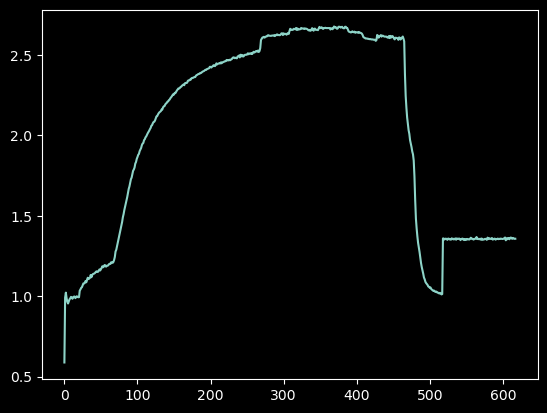

In [201]:
x, y = np.array(data['Fluo']), np.array(data['Fluoref'])
plt.plot(x/y)
# if "730" in data:
#     plt.twinx()
#     plt.plot(data['730'] / data['730ref'], 'm')
#     plt.twinx()
#     plt.plot(data['SUN'], 'y')
#     plt.twinx()
#     plt.plot(data['leaf'], 'r')



Data:Fluo,Length:500	3596,3726,3755,3777,3801,3802,3805,3812,3831,3844,3840,3844,3859,3868,3874,3868,3868,3888,3903,3903,3898,3900,3916,3918,3934,3924,3934,3940,3953,3955,3949,3950,3967,3966,3973,3960,3973,3984,3993,3991,3984,4003,4012,4008,4010,4007,4020,4025,4031,4031,4023,4033,4043,4051,4041,4052,4056,4063,4066,4059,4062,4073,4084,4077,4079,4084,4091,4091,4093,4089,4108,4113,4114,4105,4103,4114,4126,4130,4120,4122,4131,4142,4147,4136,4139,4147,4156,4161,4147,4152,4156,4173,4177,4172,4172,4187,4189,4187,4182,4182,4199,4201,4206,4193,4208,4208,4213,4208,4207,4217,4225,4238,4229,4217,4239,4248,4248,4239,4243,4242,4266,4261,4256,4259,4264,4275,4281,4270,4262,4292,4292,4295,4283,4280,4301,4317,4309,4293,4308,4314,4326,4316,4311,4322,4323,4332,4331,4333,4344,4340,4352,4347,4346,4355,4355,4364,4355,4361,4364,4371,4381,4377,4376,4383,4384,4389,4385,4394,4392,4403,4408,4402,4406,4418,4421,4423,4417,4411,4433,4441,4438,4434,4433,4450,4452,4441,4443,4449,4469,4472,4467,4453,4469,4480,4479,4472

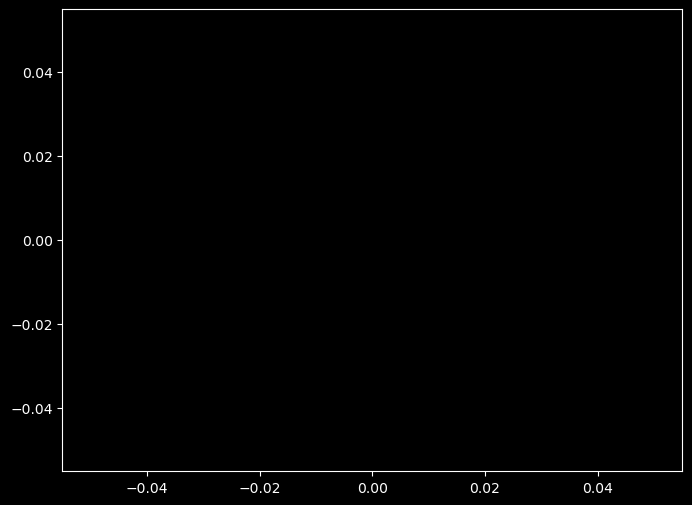

In [40]:
fig, ax = plt.subplots(1, 1, figsize = (8, 6))
line = ax.plot([], 'w-')[0]
outputs = ""
with serial.Serial("COM31", 115200) as ser:
    start_timer = time.time()
    #ser.write("mpf, 0, 100, 100".encode())
    ser.write("arrun, 500, 500, 0, 0, 0".encode())
    arr = []
    last_update_time,  last_update_length = 0, 0

    while (time.time() - start_timer < 60):
        if ser.in_waiting > 2:
            start_timer = time.time()
            l = ser.readline().decode().strip()
            if l[0] == '[':
                outputs += l + "\n"
            elif (l[0].isdigit() and l[-1].isdigit()) or (l[1].isdigit() and l[-1].isdigit()):
                if l.count(',') == 5:
                    _arr = np.fromstring(l, sep = ',', dtype=int).tolist()
                    arr.append(_arr)
                else:
                    print(l)
            elif l == "Done!":
                plot_arr = np.array(arr)
                break
            else:
                print(l)
        else:
            if (len(arr) - last_update_length > 1) and (time.time() - last_update_time > .1):
                plot_arr = np.array(arr)
                line.set_data(np.arange(plot_arr.shape[0]), plot_arr[:, 0])
                ax.autoscale_view(True, True) 
                ax.relim()
                
                last_update_length = len(arr)
                last_update_time = time.time()
                display(fig)
                clear_output(wait=True)

                plt.pause(0.0001)
            else:
                time.sleep(0.2)

                


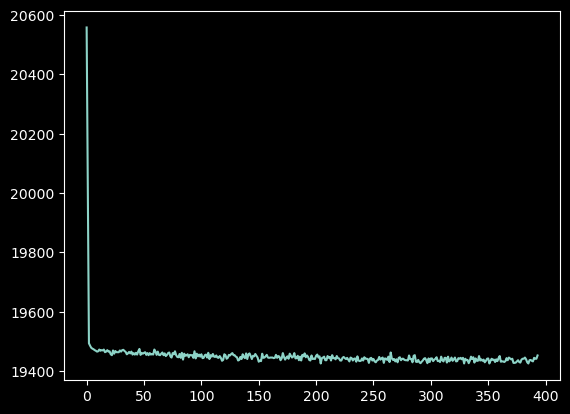

In [36]:
plt.plot(plot_arr[:,1])

In [37]:
plot_arr.shape

(394, 6)

In [17]:
tl = []

for x in range(20):
    tl += [x * 500000]
    
_z = tl[-1] + 1500
for x in range(4):
    tl += (np.arange(12) * 120 + x * 1500 + _z).tolist()

_z = tl[-1] + 1500
for x in range(200):
    tl += [x * 1500 + _z]


_z = tl[-1] + 1500
for _ in range(8):
    _z = tl[-1] + 1500
    for x in range(20):
        tl += [x * 1200 + _z]

_z = tl[-1] + 1500
for x in range(50):
    tl += [x * 1500 * 4 + _z]


_z = tl[-1] + 1500
inv = 1000
for x in range(40):
    tl += [x * 1500 * 4 + x * inv + _z]
    inv += 5000

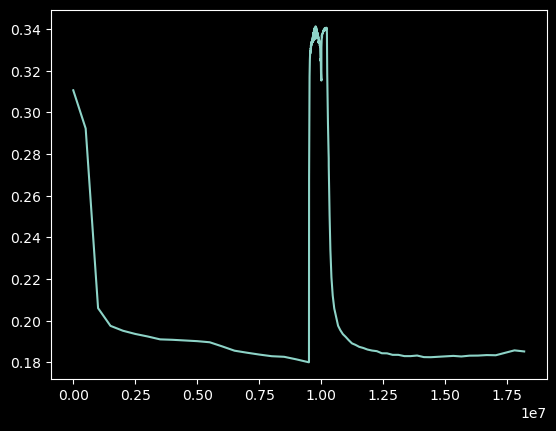

In [25]:
plt.plot(tl[:], plot_arr[:, 0] / plot_arr[:, 1], '-')
#plt.xscale('log')

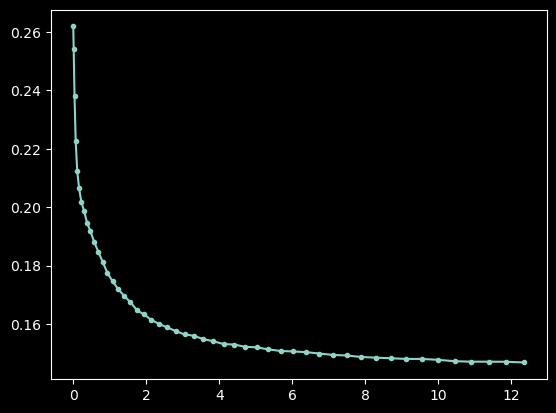

In [143]:
plt.plot((np.array(tl[-50:]) - tl[-50])/1e6, plot_arr[-50:, 0] / plot_arr[-50:, 1], '.-')
#plt.xscale('log')

In [61]:
print(outputs)

[  4942][V][u_adpd6100.cpp:584] preset_config_1(): [ADPD] Preset_config 1 set for timeslot:0. Two ambient channels. Total 6 bytes
[  4943][V][u_adpd6100.cpp:631] preset_config_2(): [ADPD] Preset_config 2 set for timeslot:1. Total 8 bytes
[  4953][I][PAM.cpp:37] detector_preset_1(): [PAM] Preset 1 set
[  4958][V][do_c.cpp:83] detector_preset(): [DO_C] ADPD detector preset with current: 50
[  4965][V][do_c.cpp:43] arr_set(): [DO_C] Set line 0 to type 1 with 100 x 10Hz samples, actinic:0, sub:1
[  4975][V][PAM.cpp:74] run_preprocess(): [PAM] Run type:1, number:100, freq: 10, actinic: 0, subfactor 1
[  4984][V][PAM.cpp:112] run_arr(): [PAM] Sample: 100, ref: 100, amb: 100, dark: 100
[  4991][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created
[  4998][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created
[  5004][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created
[  5011][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created
[  5017][V][data

In [48]:

def line_parse(l:str)->str:
    l = l.strip()
    if len(l) < 1:return ""
    if l[0] == '[':
        print(l)
        return ""
    else:
        return l.strip()

with serial.Serial("COM4", 115200, timeout = 5) as ser:


    ser.write(cmd_str.encode())
    data_ready = False
    checked = False
    ts = time.time()
    while time.time() - ts < 1:
        if ser.in_waiting > 0:
            l = line_parse(ser.readline().decode())
            if l == "Wake!":
                ser.write("Ready".encode())
                data_ready = True
            elif data_ready and l.isdigit():
                ts = time.time()
                data_len = int(l)
                ser.write("GO".encode())
                a1 = ser.read(4 * (data_len + 1))
                _a = np.frombuffer(a1, dtype=">i4")
                if (_a[:-1].sum() == _a[-1]):
                    checked = True
            elif l == "DONE":
                ser.write("Check".encode())
                data_ready = False
                print(_a)

            elif l == "Finish":
                print(l)
                break
            else:
                print(l)

                

6
[ 35920][V][u_adpd6100.cpp:584] preset_config_1(): [ADPD] Preset_config 1 set for timeslot:0. Two ambient channels. Total 6 bytes

[ 35921][V][u_adpd6100.cpp:631] preset_config_2(): [ADPD] Preset_config 2 set for timeslot:1. Total 8 bytes

[ 35931][I][PAM.cpp:37] detector_preset_1(): [PAM] Preset 1 set

[ 35936][V][do_c.cpp:83] detector_preset(): [DO_C] ADPD detector preset with current: 110

[ 35943][V][do_c.cpp:43] arr_set(): [DO_C] Set line 0 to type 1 with 50 x 50Hz samples, actinic:50, sub:1

[ 35953][V][PAM.cpp:74] run_preprocess(): [PAM] Run type:1, number:50, freq: 50, actinic: 50, subfactor 1

[ 35962][V][PAM.cpp:112] run_arr(): [PAM] Sample: 50, ref: 50, amb: 50, dark: 50

[ 35969][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created

[ 35976][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created

[ 35982][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created

[ 35989][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created

[ 3599

In [41]:
_a[:-1].sum()

6932649

In [40]:
_a

array([56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363,  7503])

In [20]:
l

'200'